In [2]:
# Cell 1: Imports and Setup
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import torch
from torch.utils.data import Dataset, DataLoader

# Add project root
project_root = Path('../../').resolve()
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

Project root: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel
PyTorch version: 2.9.0+cu128


In [11]:
# # Cell 2: Load Raw Data
# DATA_PATH = project_root / 'data' / 'raw' / 'Air_Quality_UCI' / 'air_quality' / 'AirQualityUCI.csv'

# # The CSV uses ; as separator and , as decimal
# raw_df = pd.read_csv(
#     DATA_PATH,
#     sep=';',
#     decimal=',',
#     na_values=-200,
#     parse_dates={'datetime': ['Date', 'Time']},
#     dayfirst=True,
#     infer_datetime_format=True
# )

# # Drop completely empty trailing columns (the CSV has trailing ;; )
# raw_df = raw_df.dropna(axis=1, how='all')

# # Drop rows that are entirely NaN (end of file padding)
# raw_df = raw_df.dropna(how='all')

# print(f"Shape: {raw_df.shape}")
# print(f"Date range: {raw_df['datetime'].min()} → {raw_df['datetime'].max()}")
# print(f"\nColumns:\n{raw_df.columns.tolist()}")
# raw_df.head(10)

# Cell 2: Load Raw Data
DATA_PATH = project_root / 'data' / 'raw' / 'Air_Quality_UCI' / 'air_quality' / 'AirQualityUCI.csv'

# The CSV uses ; as separator and , as decimal
raw_df = pd.read_csv(
    DATA_PATH,
    sep=';',
    decimal=',',
    na_values=-200,
)

# Drop completely empty trailing columns (the CSV has trailing ;; )
raw_df = raw_df.dropna(axis=1, how='all')

# Drop rows that are entirely NaN (end of file padding)
raw_df = raw_df.dropna(how='all')

# Fix time format: "18.00.00" → "18:00:00", then combine Date + Time into datetime
raw_df['Time'] = raw_df['Time'].astype(str).str.replace('.', ':', regex=False)
raw_df['datetime'] = pd.to_datetime(
    raw_df['Date'].astype(str) + ' ' + raw_df['Time'],
    dayfirst=True,
    format='mixed'
)

# Drop the original Date and Time columns
raw_df = raw_df.drop(columns=['Date', 'Time'])

# Move datetime to the front
cols = ['datetime'] + [c for c in raw_df.columns if c != 'datetime']
raw_df = raw_df[cols]

print(f"Shape: {raw_df.shape}")
print(f"Date range: {raw_df['datetime'].min()} → {raw_df['datetime'].max()}")
print(f"datetime dtype: {raw_df['datetime'].dtype}")
print(f"\nColumns:\n{raw_df.columns.tolist()}")
raw_df.head(10)

Shape: (9357, 14)
Date range: 2004-03-10 18:00:00 → 2005-04-04 14:00:00
datetime dtype: datetime64[ns]

Columns:
['datetime', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


,datetime,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
5,2004-03-10 23:00:00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848
6,2004-03-11 00:00:00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603
7,2004-03-11 01:00:00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702
8,2004-03-11 02:00:00,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648
9,2004-03-11 03:00:00,0.6,1010.0,19.0,1.7,561.0,NaN,1705.0,NaN,1235.0,501.0,10.3,60.2,0.7517


In [4]:
# Cell 3: Basic Info & Data Types
print("="*60)
print("DATA TYPES")
print("="*60)
print(raw_df.dtypes)
print(f"\n{'='*60}")
print("BASIC STATISTICS")
print(f"{'='*60}")
raw_df.describe()

DATA TYPES
datetime          object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object

BASIC STATISTICS


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


MISSING VALUES ANALYSIS
               Missing Count  Missing %
NMHC(GT)                8557      90.35
CO(GT)                  1797      18.97
NO2(GT)                 1756      18.54
NOx(GT)                 1753      18.51
C6H6(GT)                 480       5.07
PT08.S1(CO)              480       5.07
PT08.S5(O3)              480       5.07
PT08.S2(NMHC)            480       5.07
PT08.S3(NOx)             480       5.07
PT08.S4(NO2)             480       5.07
RH                       480       5.07
T                        480       5.07
AH                       480       5.07
datetime                   0       0.00

Total rows: 9471
Rows with any NaN: 8644


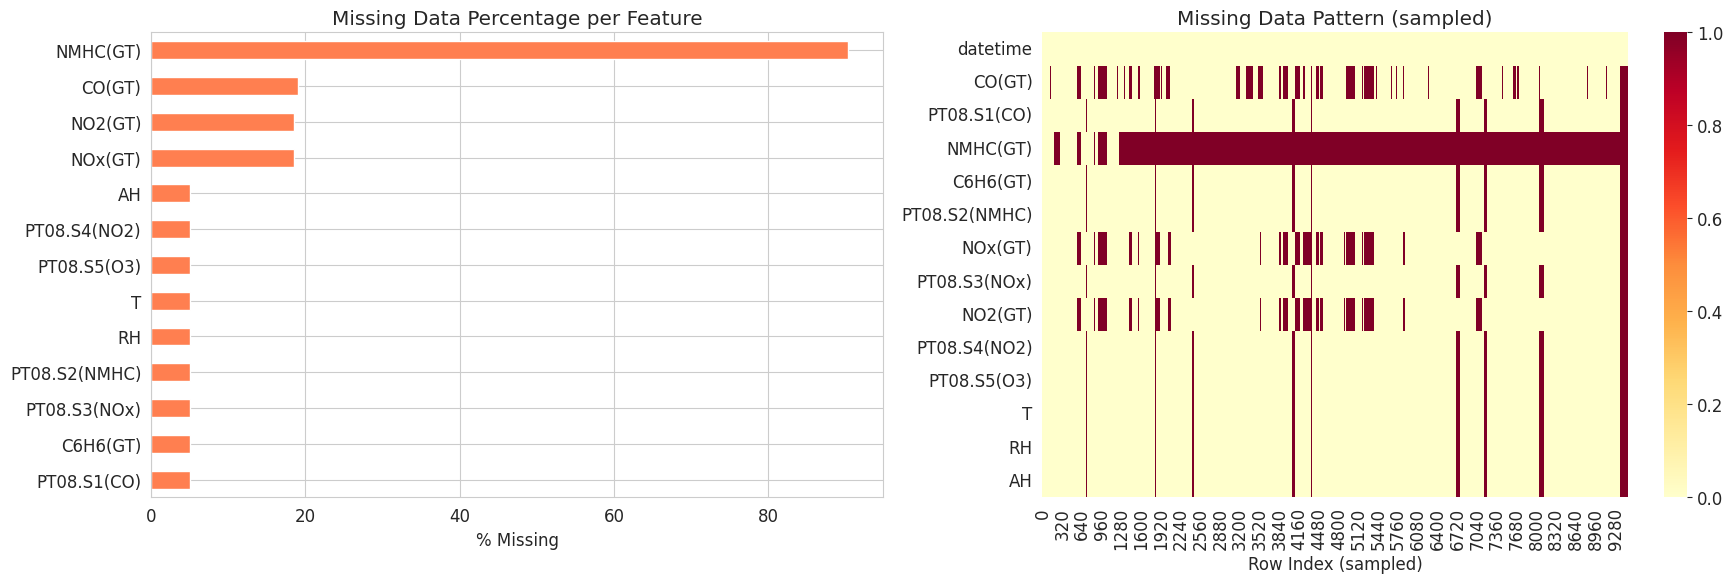

In [5]:
# Cell 4: Missing Value Analysis
print("="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)

# -200 was already converted to NaN during loading
missing_counts = raw_df.isnull().sum()
missing_pct = (raw_df.isnull().sum() / len(raw_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print(missing_df)
print(f"\nTotal rows: {len(raw_df)}")
print(f"Rows with any NaN: {raw_df.isnull().any(axis=1).sum()}")

# Visualize missing pattern
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart of missing %
missing_pct_nonzero = missing_pct[missing_pct > 0].sort_values(ascending=True)
missing_pct_nonzero.plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Missing Data Percentage per Feature')
axes[0].set_xlabel('% Missing')

# Missing data heatmap (sample every 10th row for visibility)
sns.heatmap(raw_df.iloc[::10].isnull().T, cbar=True, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Missing Data Pattern (sampled)')
axes[1].set_xlabel('Row Index (sampled)')

plt.tight_layout()
plt.savefig(str(project_root / 'outputs' / 'air_quality_missing_values.png'), dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Cell 5: Feature Descriptions
"""
Air Quality UCI Dataset - Feature Description:
================================================
- CO(GT)         : True hourly avg CO concentration (mg/m³) — reference analyzer
- PT08.S1(CO)    : Tin oxide sensor response (nominally CO targeted)
- NMHC(GT)       : True hourly avg Non-Metanic HydroCarbons (µg/m³) — reference
- C6H6(GT)       : True hourly avg Benzene concentration (µg/m³) — reference
- PT08.S2(NMHC)  : Titania sensor response (nominally NMHC targeted)
- NOx(GT)        : True hourly avg NOx concentration (ppb) — reference
- PT08.S3(NOx)   : Tungsten oxide sensor response (nominally NOx targeted)
- NO2(GT)        : True hourly avg NO2 concentration (µg/m³) — reference
- PT08.S4(NO2)   : Tungsten oxide sensor response (nominally NO2 targeted)
- PT08.S5(O3)    : Indium oxide sensor response (nominally O3 targeted)
- T              : Temperature (°C)
- RH             : Relative Humidity (%)
- AH             : Absolute Humidity

Note: NMHC(GT) has ~90% missing → will be dropped.
      -200 values indicate missing (already handled as NaN).
"""

# Sensor columns vs ground truth columns
sensor_cols = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
gt_cols = ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
meteo_cols = ['T', 'RH', 'AH']

print("Sensor columns:", sensor_cols)
print("Ground truth columns:", gt_cols)
print("Meteorological columns:", meteo_cols)

Sensor columns: ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
Ground truth columns: ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
Meteorological columns: ['T', 'RH', 'AH']


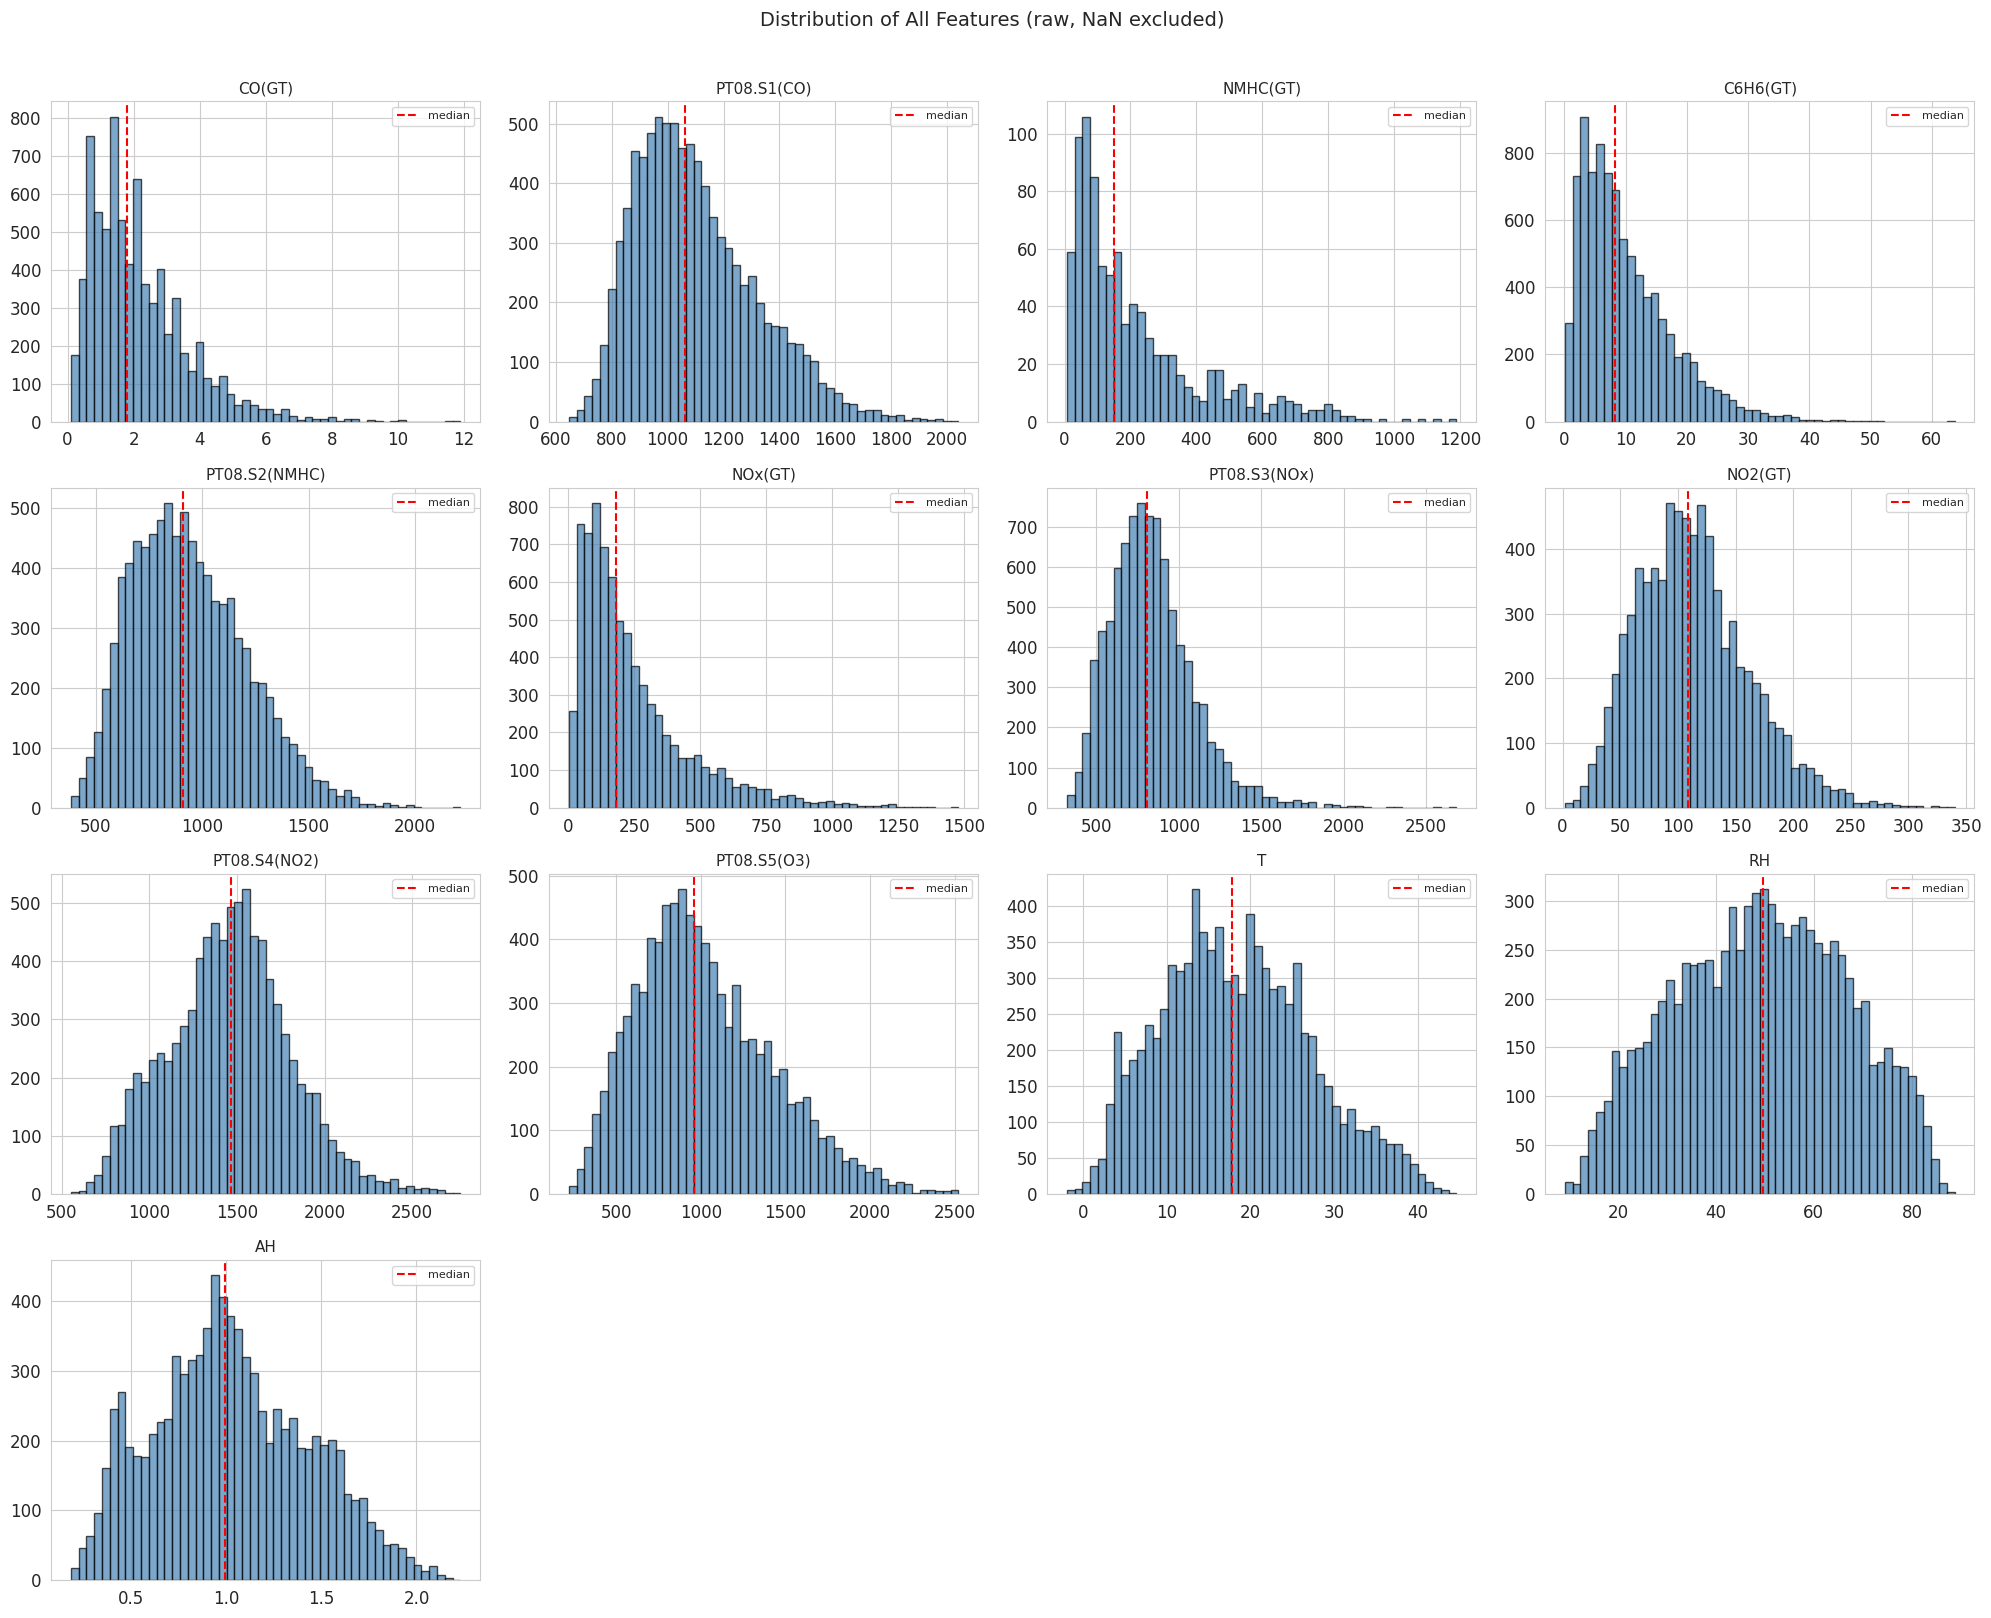

In [7]:
# Cell 6: Distribution of All Features
feature_cols = [c for c in raw_df.columns if c != 'datetime']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    if i < len(axes):
        raw_df[col].dropna().hist(bins=50, ax=axes[i], color='steelblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(col, fontsize=11)
        axes[i].axvline(raw_df[col].median(), color='red', linestyle='--', label='median')
        axes[i].legend(fontsize=8)

# Hide extra subplots
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Features (raw, NaN excluded)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(str(project_root / 'outputs' / 'air_quality_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

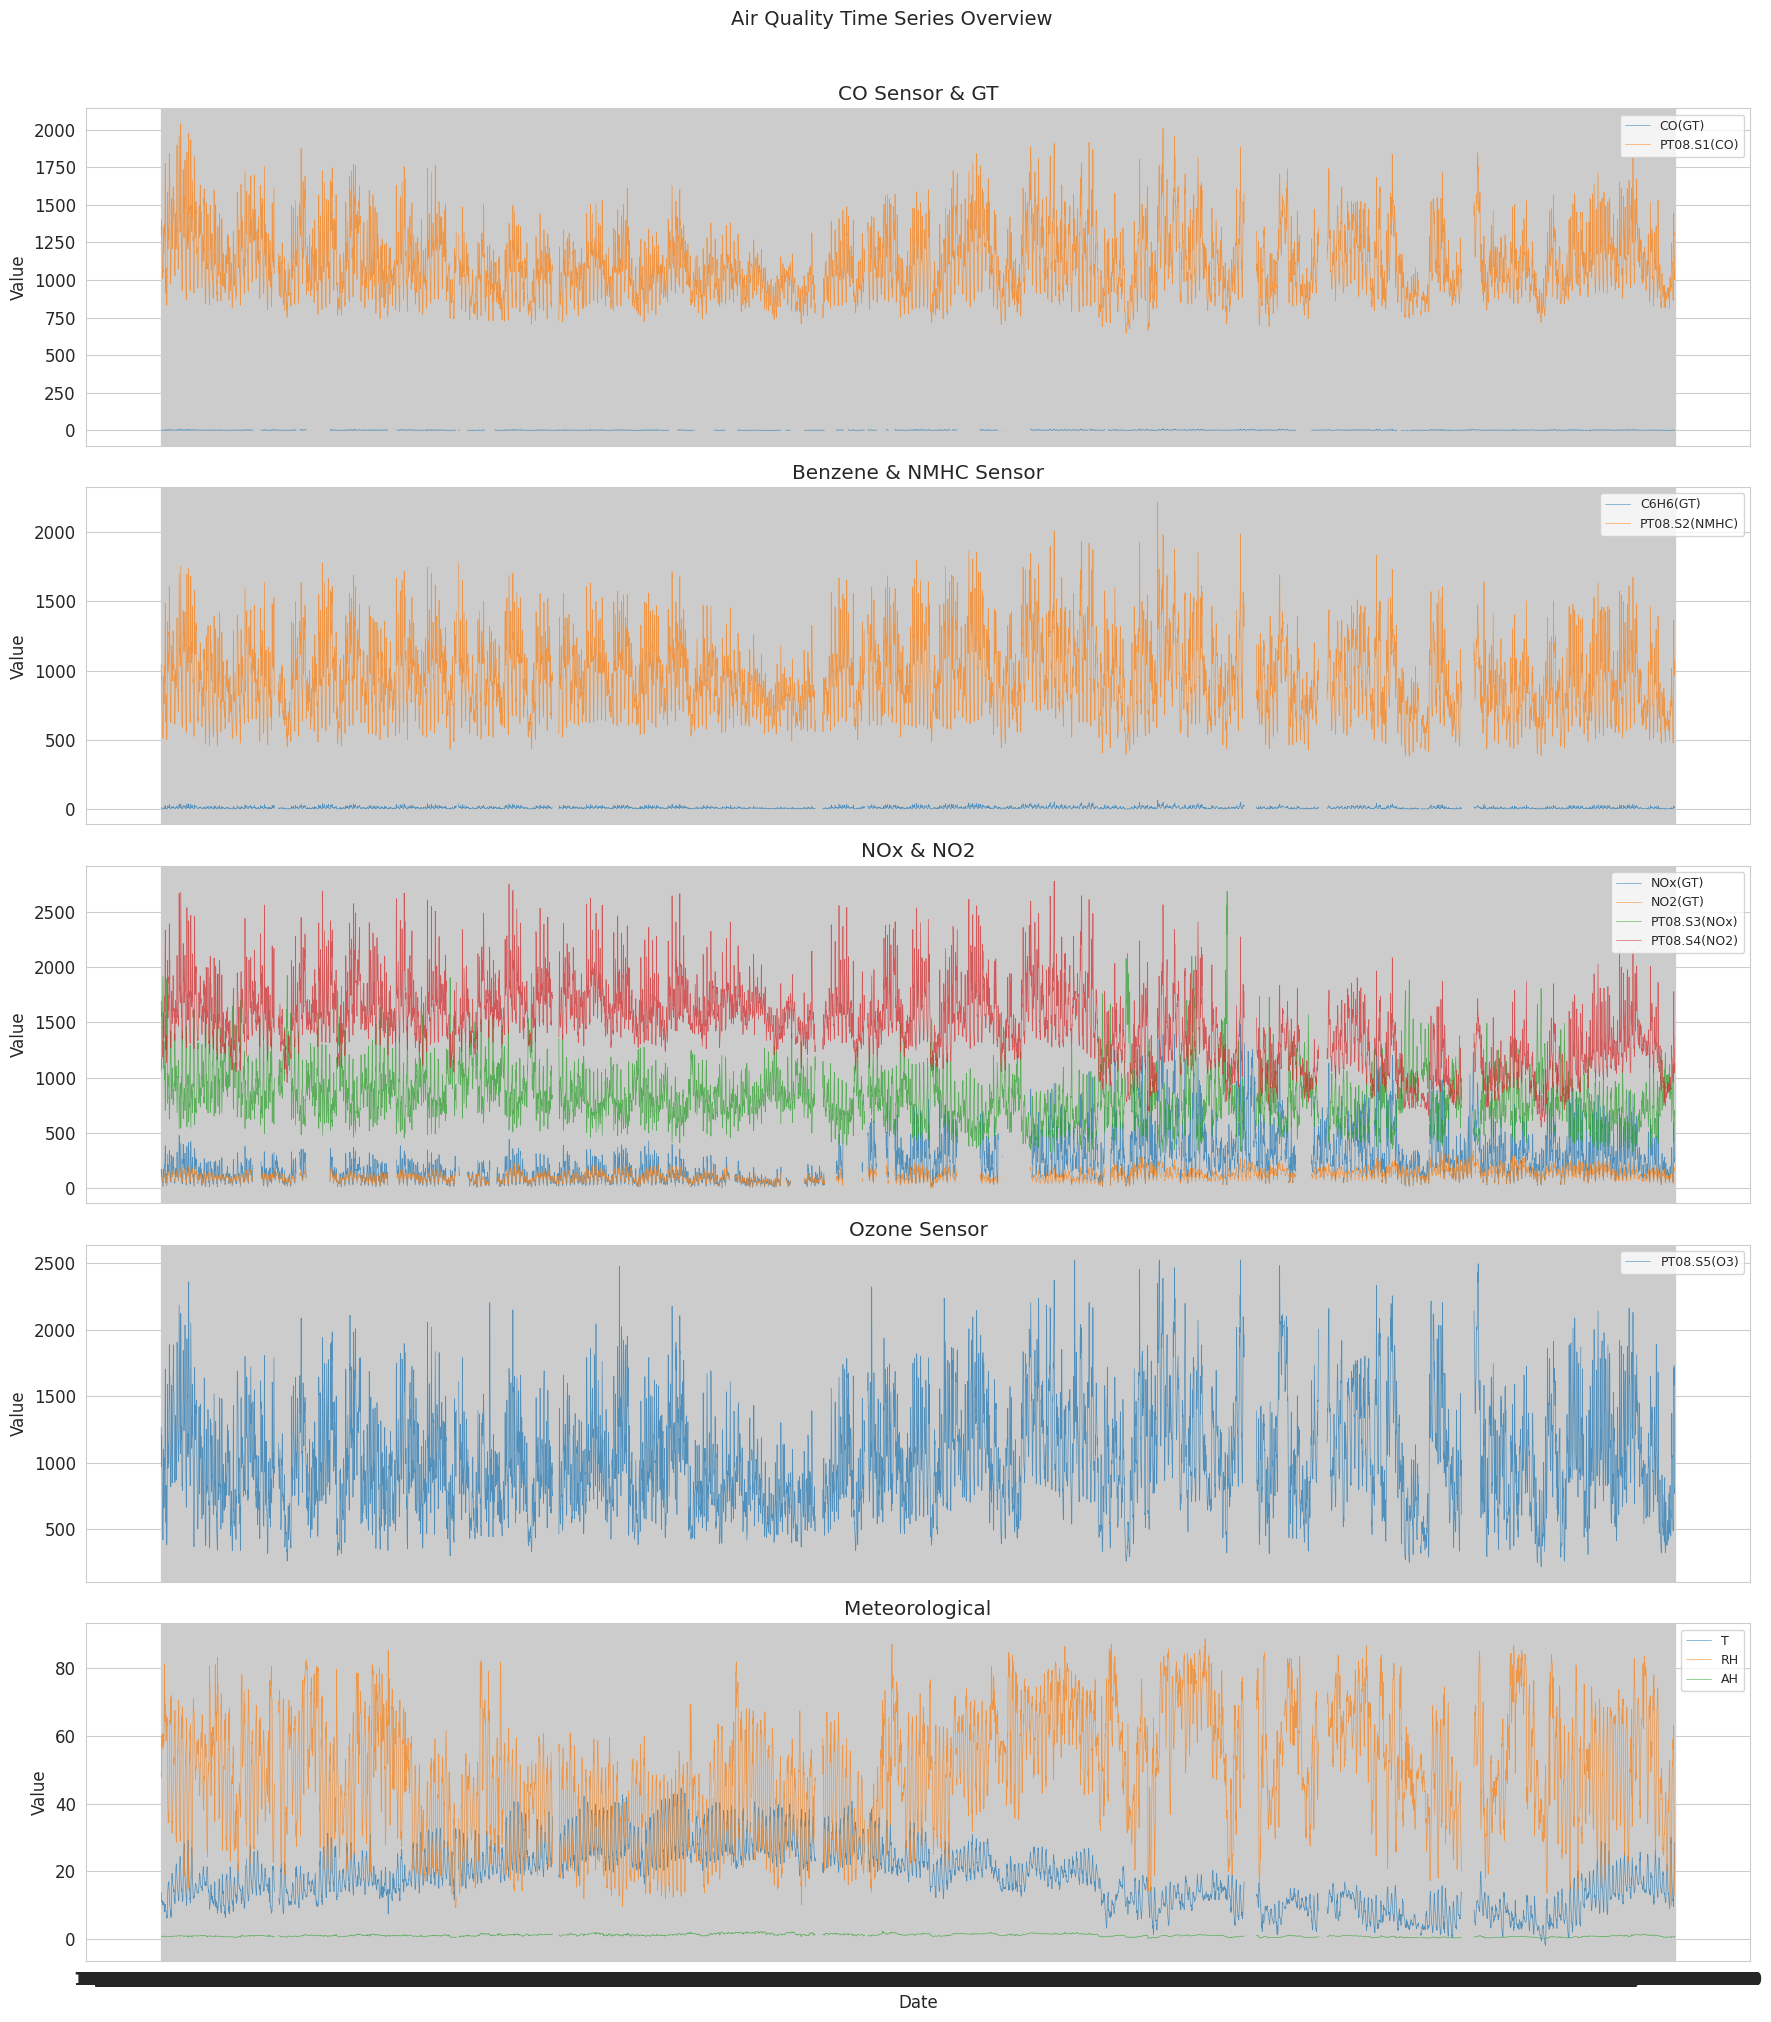

In [8]:
# Cell 7: Time Series Visualization
fig, axes = plt.subplots(5, 1, figsize=(18, 20), sharex=True)

# Plot sensor readings over time
plot_groups = [
    ('CO Sensor & GT', ['CO(GT)', 'PT08.S1(CO)']),
    ('Benzene & NMHC Sensor', ['C6H6(GT)', 'PT08.S2(NMHC)']),
    ('NOx & NO2', ['NOx(GT)', 'NO2(GT)', 'PT08.S3(NOx)', 'PT08.S4(NO2)']),
    ('Ozone Sensor', ['PT08.S5(O3)']),
    ('Meteorological', ['T', 'RH', 'AH']),
]

for ax, (title, cols) in zip(axes, plot_groups):
    for col in cols:
        ax.plot(raw_df['datetime'], raw_df[col], label=col, alpha=0.7, linewidth=0.5)
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylabel('Value')

axes[-1].set_xlabel('Date')
plt.suptitle('Air Quality Time Series Overview', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(str(project_root / 'outputs' / 'air_quality_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

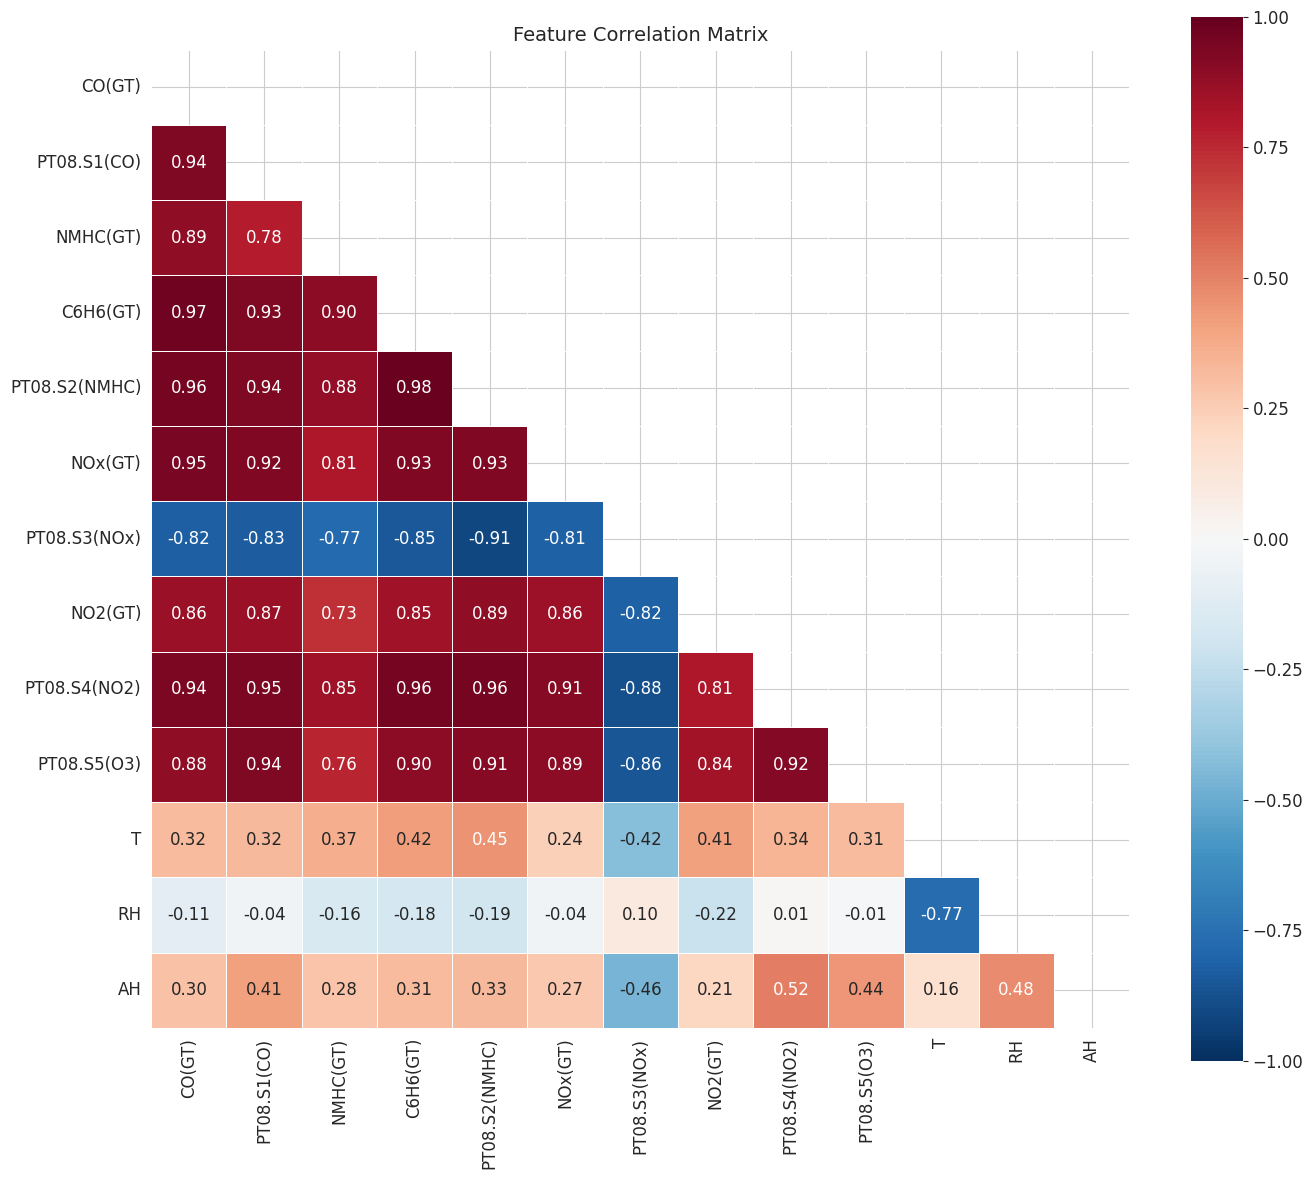

In [9]:
# Cell 8: Correlation Analysis
numeric_df = raw_df.drop(columns=['datetime']).dropna()

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True, ax=ax,
    linewidths=0.5, vmin=-1, vmax=1
)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(str(project_root / 'outputs' / 'air_quality_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

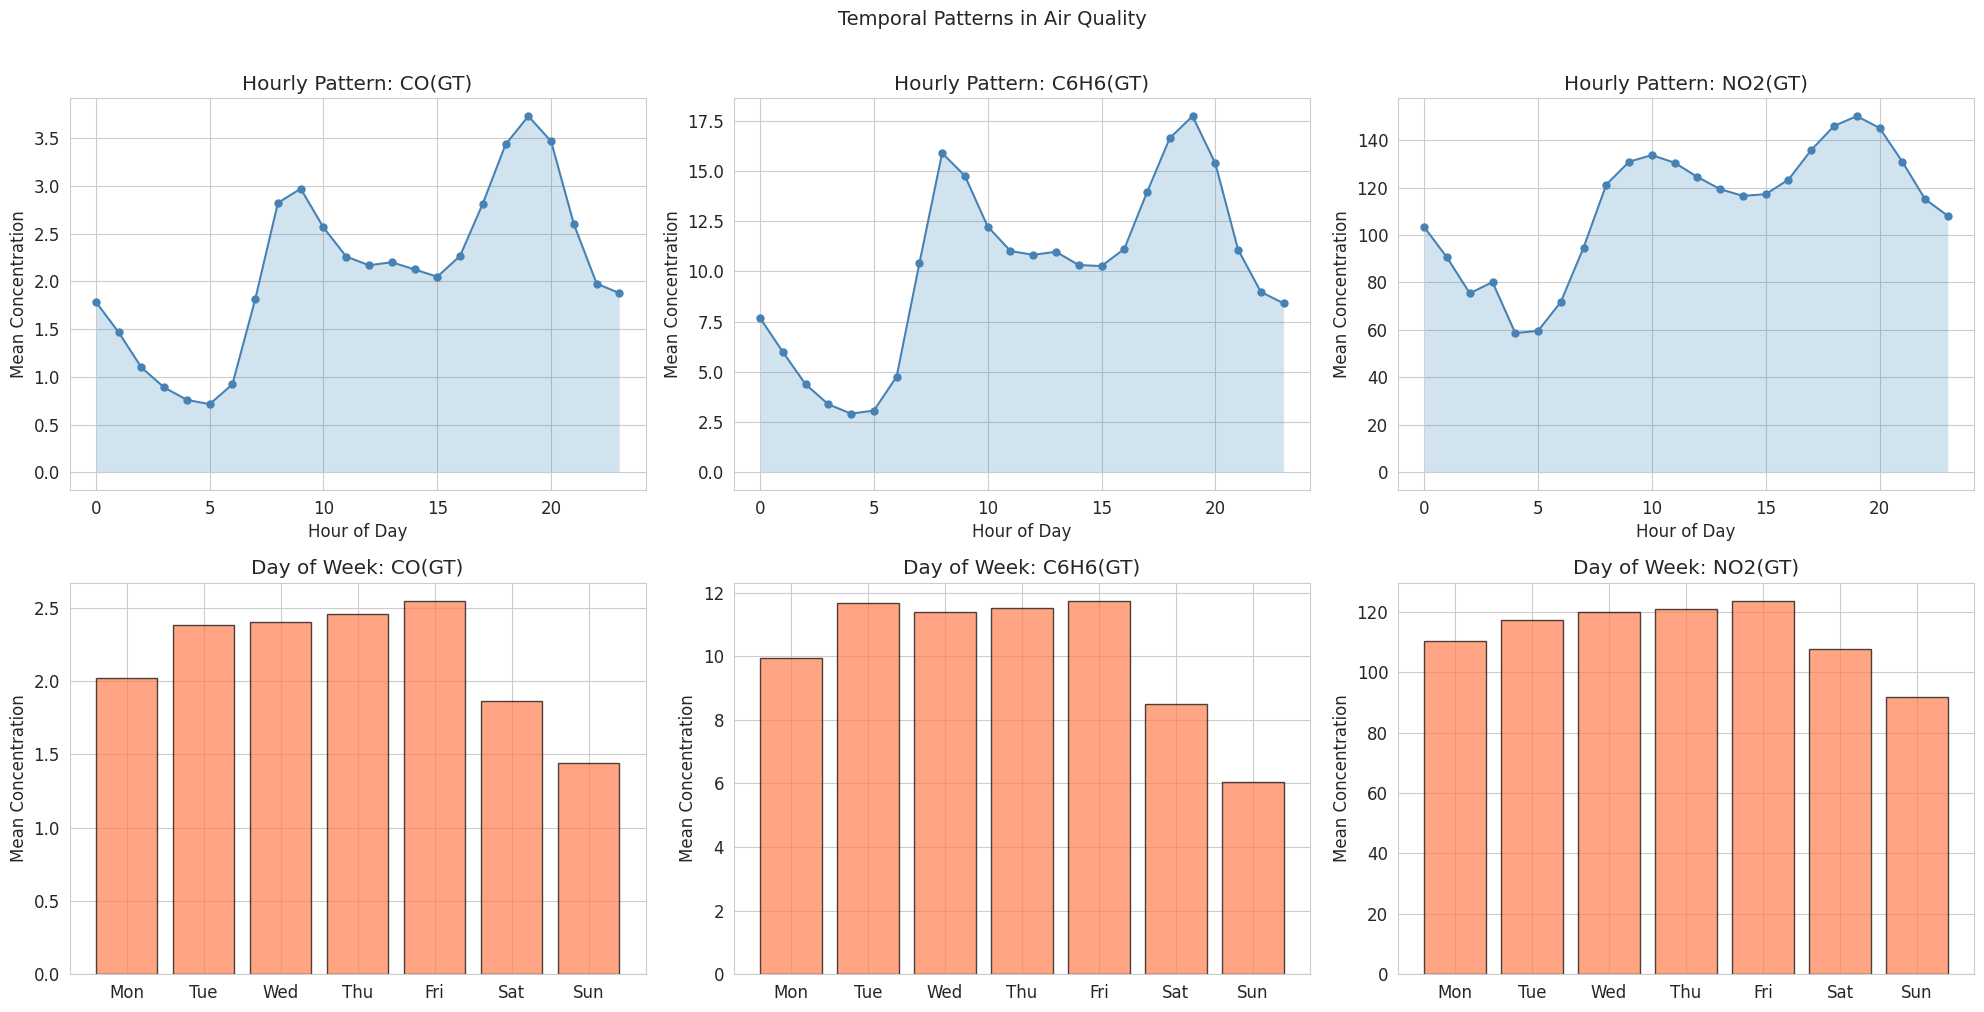

In [12]:
# Cell 9: Temporal Patterns - Hourly and Daily
df_temp = raw_df.copy()
df_temp['hour'] = df_temp['datetime'].dt.hour
df_temp['dayofweek'] = df_temp['datetime'].dt.dayofweek
df_temp['month'] = df_temp['datetime'].dt.month

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Hourly patterns
for ax, col in zip(axes[0], ['CO(GT)', 'C6H6(GT)', 'NO2(GT)']):
    hourly = df_temp.groupby('hour')[col].mean()
    ax.plot(hourly.index, hourly.values, 'o-', color='steelblue', markersize=5)
    ax.fill_between(hourly.index, hourly.values, alpha=0.2)
    ax.set_title(f'Hourly Pattern: {col}')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Mean Concentration')

# Day of week patterns
for ax, col in zip(axes[1], ['CO(GT)', 'C6H6(GT)', 'NO2(GT)']):
    daily = df_temp.groupby('dayofweek')[col].mean()
    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    ax.bar(range(7), daily.values, color='coral', edgecolor='black', alpha=0.7)
    ax.set_xticks(range(7))
    ax.set_xticklabels(days)
    ax.set_title(f'Day of Week: {col}')
    ax.set_ylabel('Mean Concentration')

plt.suptitle('Temporal Patterns in Air Quality', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(str(project_root / 'outputs' / 'air_quality_temporal_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()

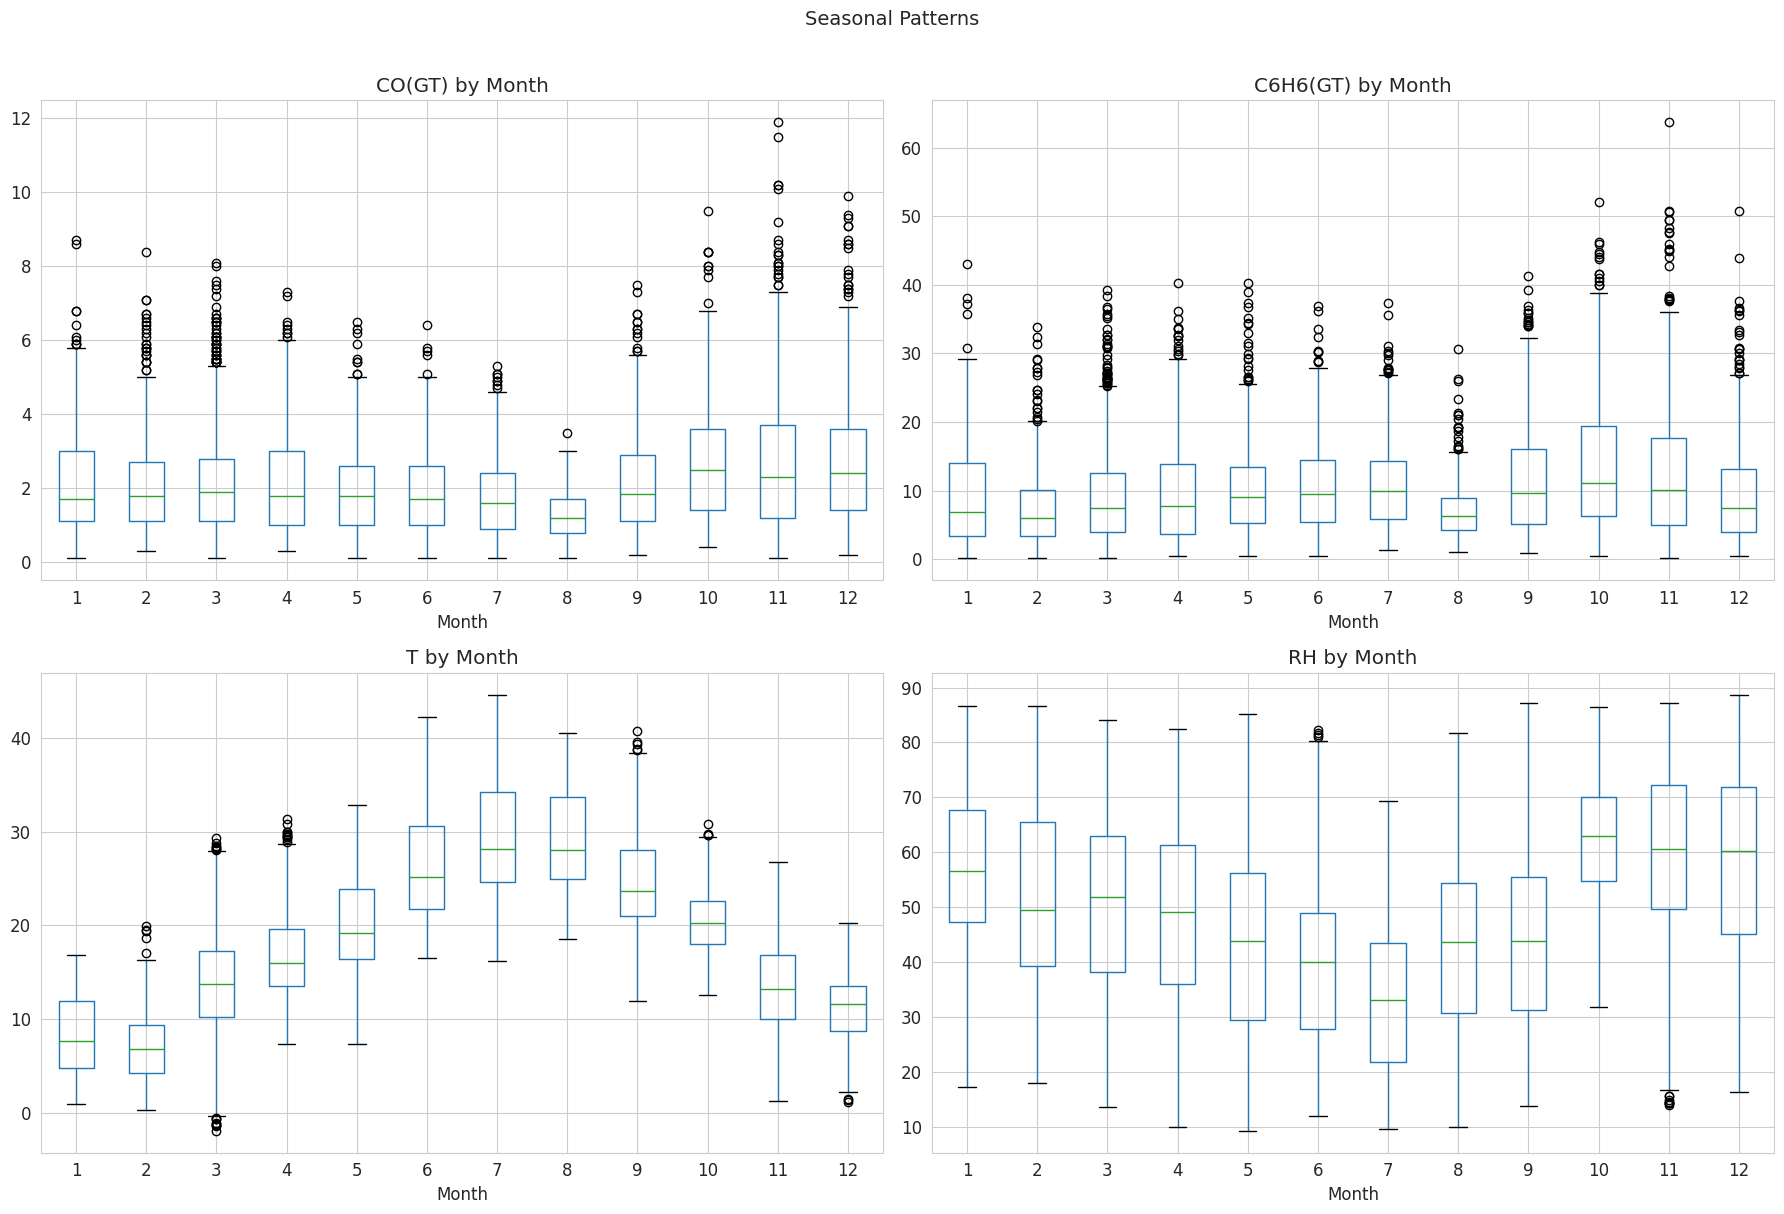

In [13]:
# Cell 10: Box Plots by Month (Seasonality)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plot_cols = ['CO(GT)', 'C6H6(GT)', 'T', 'RH']

for ax, col in zip(axes.flatten(), plot_cols):
    df_temp.boxplot(column=col, by='month', ax=ax)
    ax.set_title(f'{col} by Month')
    ax.set_xlabel('Month')

plt.suptitle('Seasonal Patterns', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(str(project_root / 'outputs' / 'air_quality_seasonal.png'), dpi=150, bbox_inches='tight')
plt.show()

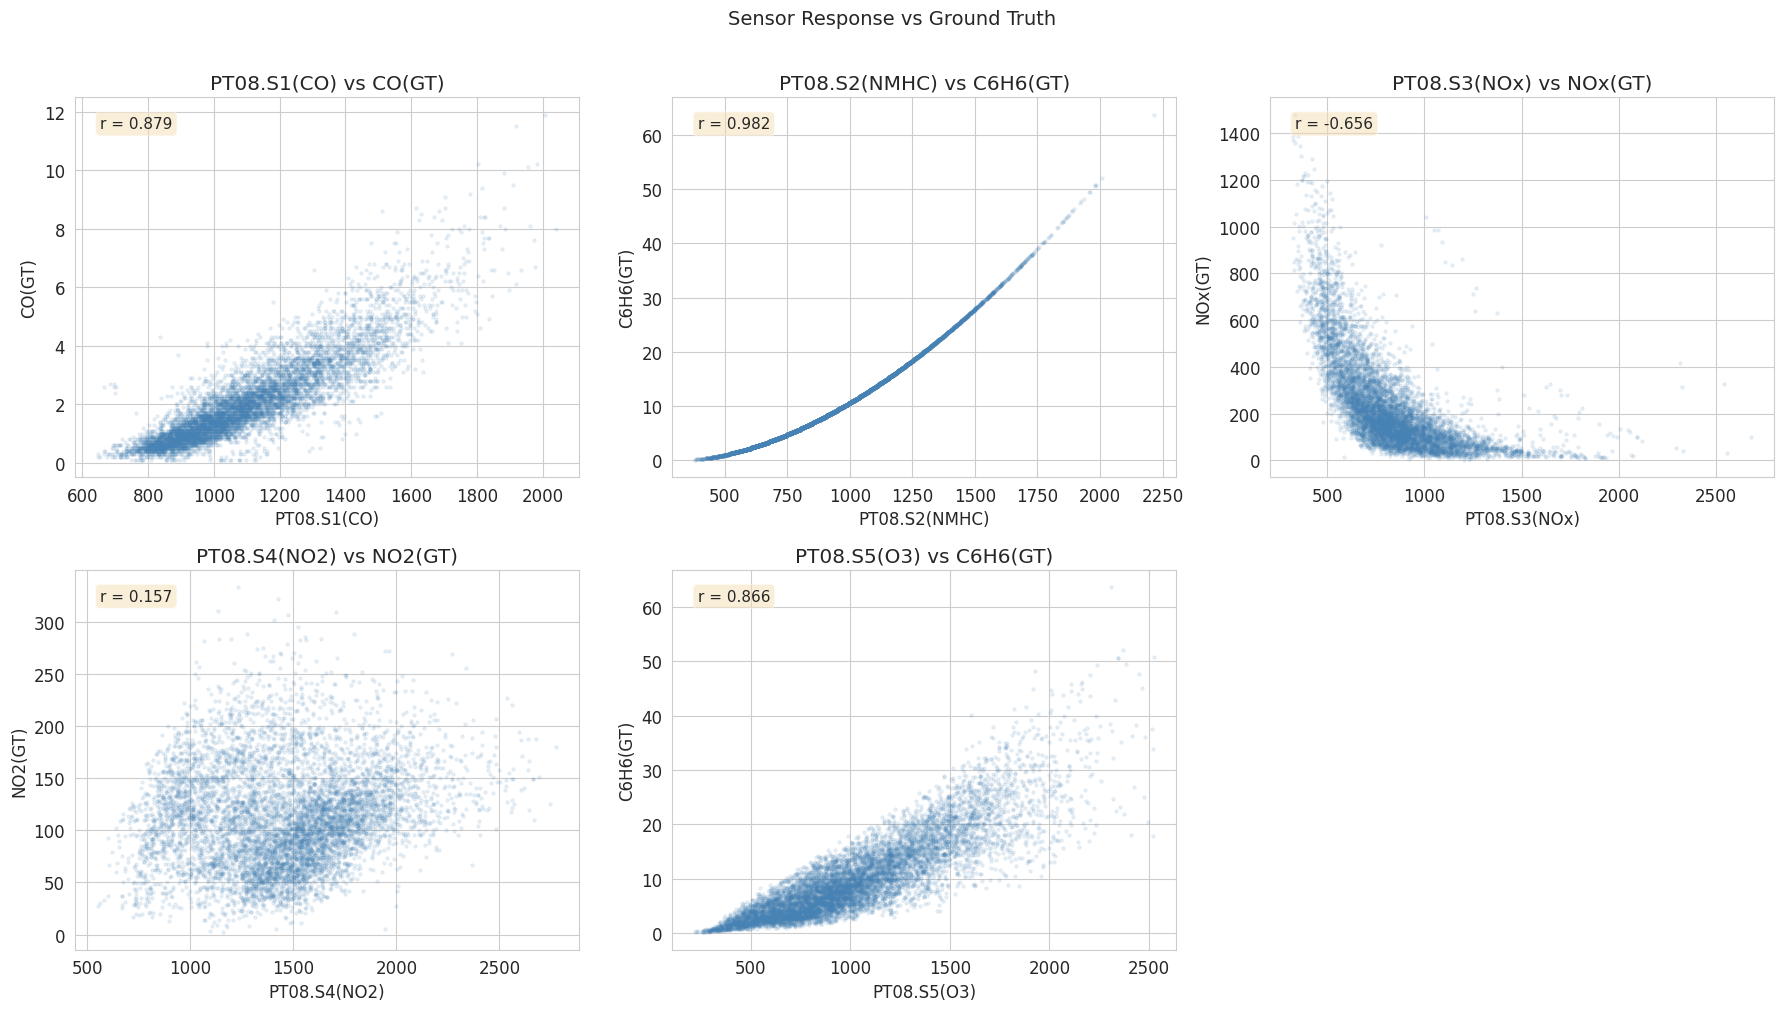

In [14]:
# Cell 11: Sensor vs Ground Truth Scatter Plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

sensor_gt_pairs = [
    ('PT08.S1(CO)', 'CO(GT)'),
    ('PT08.S2(NMHC)', 'C6H6(GT)'),
    ('PT08.S3(NOx)', 'NOx(GT)'),
    ('PT08.S4(NO2)', 'NO2(GT)'),
    ('PT08.S5(O3)', 'C6H6(GT)'),
]

for i, (sensor, gt) in enumerate(sensor_gt_pairs):
    mask = raw_df[[sensor, gt]].dropna().index
    axes[i].scatter(raw_df.loc[mask, sensor], raw_df.loc[mask, gt], alpha=0.1, s=5, color='steelblue')
    axes[i].set_xlabel(sensor)
    axes[i].set_ylabel(gt)
    axes[i].set_title(f'{sensor} vs {gt}')
    
    # Add correlation coefficient
    r = raw_df.loc[mask, [sensor, gt]].corr().iloc[0, 1]
    axes[i].text(0.05, 0.95, f'r = {r:.3f}', transform=axes[i].transAxes, fontsize=11,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1].set_visible(False)
plt.suptitle('Sensor Response vs Ground Truth', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(str(project_root / 'outputs' / 'air_quality_sensor_vs_gt.png'), dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Cell 12: Data Cleaning & Preprocessing
print("="*60)
print("DATA CLEANING")
print("="*60)

df = raw_df.copy()

# 1. Drop NMHC(GT) — ~90% missing, unusable
print(f"\n1. Dropping NMHC(GT) — {raw_df['NMHC(GT)'].isnull().mean()*100:.1f}% missing")
df = df.drop(columns=['NMHC(GT)'])

# 2. Sort by datetime and set as index
df = df.sort_values('datetime').reset_index(drop=True)

# 3. Check for duplicate timestamps
n_dup = df['datetime'].duplicated().sum()
print(f"2. Duplicate timestamps: {n_dup}")
if n_dup > 0:
    df = df.drop_duplicates(subset='datetime', keep='first')

# 4. Drop rows where ALL feature values are NaN
feature_cols_clean = [c for c in df.columns if c != 'datetime']
before = len(df)
df = df.dropna(subset=feature_cols_clean, how='all')
print(f"3. Dropped {before - len(df)} fully-empty rows")

# 5. Forward-fill then backward-fill for small gaps (sensor dropouts)
print(f"4. NaN before interpolation: {df[feature_cols_clean].isnull().sum().sum()}")
df[feature_cols_clean] = df[feature_cols_clean].interpolate(method='linear', limit=5)
df[feature_cols_clean] = df[feature_cols_clean].fillna(method='ffill', limit=3)
df[feature_cols_clean] = df[feature_cols_clean].fillna(method='bfill', limit=3)
print(f"   NaN after interpolation: {df[feature_cols_clean].isnull().sum().sum()}")

# 6. Drop remaining rows with NaN
before = len(df)
df = df.dropna(subset=feature_cols_clean)
print(f"5. Dropped {before - len(df)} rows with remaining NaN")

print(f"\nCleaned shape: {df.shape}")
print(f"Date range: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Total hours: {len(df)}")
df.head()

DATA CLEANING

1. Dropping NMHC(GT) — 90.2% missing
2. Duplicate timestamps: 0
3. Dropped 31 fully-empty rows
4. NaN before interpolation: 7886
   NaN after interpolation: 5503
5. Dropped 1550 rows with remaining NaN

Cleaned shape: (7776, 13)
Date range: 2004-03-10 18:00:00 → 2005-04-04 14:00:00
Total hours: 7776


/tmp/ipykernel_495441/2203383286.py:30: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols_clean] = df[feature_cols_clean].fillna(method='ffill', limit=3)
/tmp/ipykernel_495441/2203383286.py:31: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols_clean] = df[feature_cols_clean].fillna(method='bfill', limit=3)


,datetime,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [16]:
# Cell 13: Define Task — Multivariate Time Series Forecasting
"""
TASK DEFINITION
===============
We treat this as a univariate or multivariate regression task:
- Input: Window of past `seq_len` hours of ALL features  
- Output: Next-hour prediction of a TARGET variable (e.g., CO(GT) or C6H6(GT))

This is suitable for LSTM / GRU / Transformer models with shape:
  Input:  (batch_size, seq_len, num_features)
  Output: (batch_size, 1) — next-step prediction

We can easily swap the target column.
"""

# Configuration
TARGET_COL = 'C6H6(GT)'  # Benzene — good continuous target, no missing after cleaning
SEQ_LEN = 24             # Use 24 hours (1 day) of history
FORECAST_HORIZON = 1     # Predict 1 hour ahead
BATCH_SIZE = 64
VAL_RATIO = 0.15
TEST_RATIO = 0.15
SEED = 42

feature_cols_final = [c for c in df.columns if c != 'datetime']
num_features = len(feature_cols_final)

print(f"Target: {TARGET_COL}")
print(f"Sequence length: {SEQ_LEN}")
print(f"Forecast horizon: {FORECAST_HORIZON}")
print(f"Number of features: {num_features}")
print(f"Features: {feature_cols_final}")

Target: C6H6(GT)
Sequence length: 24
Forecast horizon: 1
Number of features: 12
Features: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


TEMPORAL SPLIT
Train: 5444 samples (70.0%) | 2004-03-10 18:00:00 → 2004-12-19 21:00:00
Val:   1166 samples (15.0%) | 2004-12-19 22:00:00 → 2005-02-15 00:00:00
Test:  1166 samples (15.0%) | 2005-02-15 01:00:00 → 2005-04-04 14:00:00


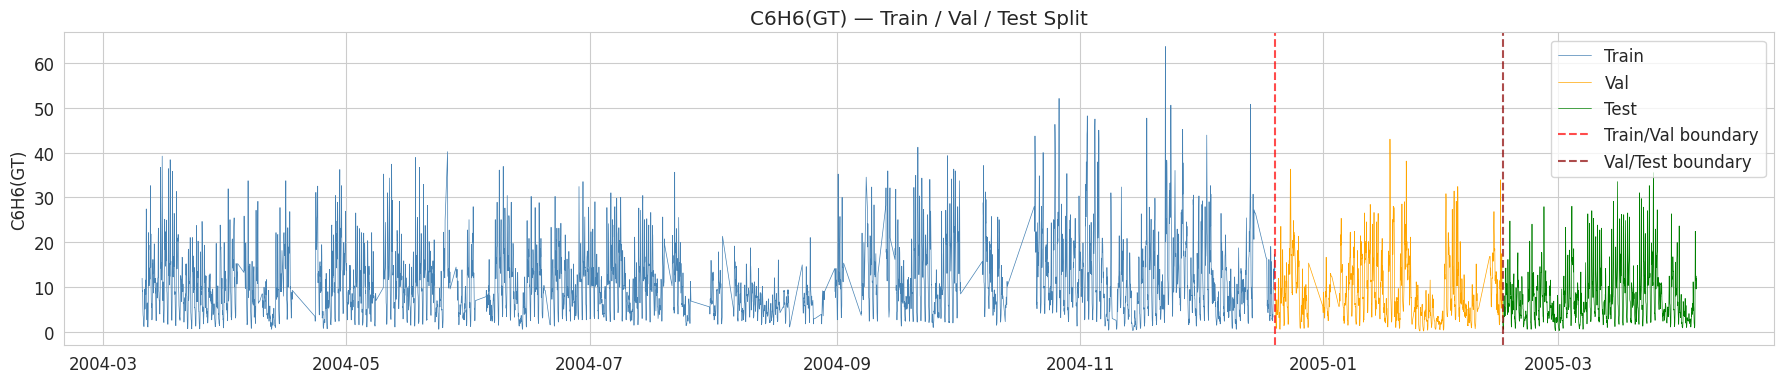

In [17]:
# Cell 14: Train / Val / Test Split (Temporal — NO SHUFFLE)
"""
For time series we MUST split chronologically:
  [--- Train ---|--- Val ---|--- Test ---]
"""

n = len(df)
n_test = int(n * TEST_RATIO)
n_val = int(n * VAL_RATIO)
n_train = n - n_val - n_test

train_df = df.iloc[:n_train].copy()
val_df = df.iloc[n_train:n_train + n_val].copy()
test_df = df.iloc[n_train + n_val:].copy()

print(f"{'='*60}")
print(f"TEMPORAL SPLIT")
print(f"{'='*60}")
print(f"Train: {len(train_df)} samples ({len(train_df)/n*100:.1f}%) | {train_df['datetime'].min()} → {train_df['datetime'].max()}")
print(f"Val:   {len(val_df)} samples ({len(val_df)/n*100:.1f}%) | {val_df['datetime'].min()} → {val_df['datetime'].max()}")
print(f"Test:  {len(test_df)} samples ({len(test_df)/n*100:.1f}%) | {test_df['datetime'].min()} → {test_df['datetime'].max()}")

# Visualize split
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(train_df['datetime'], train_df[TARGET_COL], label='Train', color='steelblue', linewidth=0.5)
ax.plot(val_df['datetime'], val_df[TARGET_COL], label='Val', color='orange', linewidth=0.5)
ax.plot(test_df['datetime'], test_df[TARGET_COL], label='Test', color='green', linewidth=0.5)
ax.axvline(val_df['datetime'].iloc[0], color='red', linestyle='--', alpha=0.7, label='Train/Val boundary')
ax.axvline(test_df['datetime'].iloc[0], color='darkred', linestyle='--', alpha=0.7, label='Val/Test boundary')
ax.set_title(f'{TARGET_COL} — Train / Val / Test Split')
ax.set_ylabel(TARGET_COL)
ax.legend()
plt.tight_layout()
plt.savefig(str(project_root / 'outputs' / 'air_quality_train_val_test_split.png'), dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Cell 15: Normalization (fit on TRAIN only)
print("="*60)
print("NORMALIZATION (Z-score, fit on train only)")
print("="*60)

train_mean = train_df[feature_cols_final].mean()
train_std = train_df[feature_cols_final].std()

# Prevent division by zero
train_std = train_std.replace(0.0, 1.0)

def normalize(df_in, mean, std, feature_cols):
    """Z-score normalize using provided stats."""
    out = df_in.copy()
    out[feature_cols] = (df_in[feature_cols] - mean) / std
    return out

def denormalize(values, col_name, mean, std):
    """Inverse z-score for a single column."""
    return values * std[col_name] + mean[col_name]

def denormalize_array(values_array, mean, std, feature_cols):
    """Inverse z-score for all features — useful for counterfactuals."""
    return values_array * std[feature_cols].values + mean[feature_cols].values

train_norm = normalize(train_df, train_mean, train_std, feature_cols_final)
val_norm = normalize(val_df, train_mean, train_std, feature_cols_final)
test_norm = normalize(test_df, train_mean, train_std, feature_cols_final)

# Sanity check: train should be ~N(0,1)
print("\nTrain normalized stats:")
print(train_norm[feature_cols_final].describe().loc[['mean', 'std']].round(4))

# Save normalization stats
norm_stats = {
    'mean': train_mean.to_dict(),
    'std': train_std.to_dict(),
    'feature_cols': feature_cols_final,
    'target_col': TARGET_COL,
    'seq_len': SEQ_LEN,
}

import json
norm_stats_path = project_root / 'outputs' / 'air_quality_preprocess.json'
with open(norm_stats_path, 'w') as f:
    json.dump(norm_stats, f, indent=4)
print(f"\n✅ Normalization stats saved to {norm_stats_path}")

NORMALIZATION (Z-score, fit on train only)

Train normalized stats:
      CO(GT)  PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  \
mean     0.0          0.0       0.0           -0.0      0.0           0.0   
std      1.0          1.0       1.0            1.0      1.0           1.0   

      NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)    T   RH   AH  
mean      0.0           0.0         -0.0 -0.0 -0.0  0.0  
std       1.0           1.0          1.0  1.0  1.0  1.0  

✅ Normalization stats saved to /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/air_quality_preprocess.json


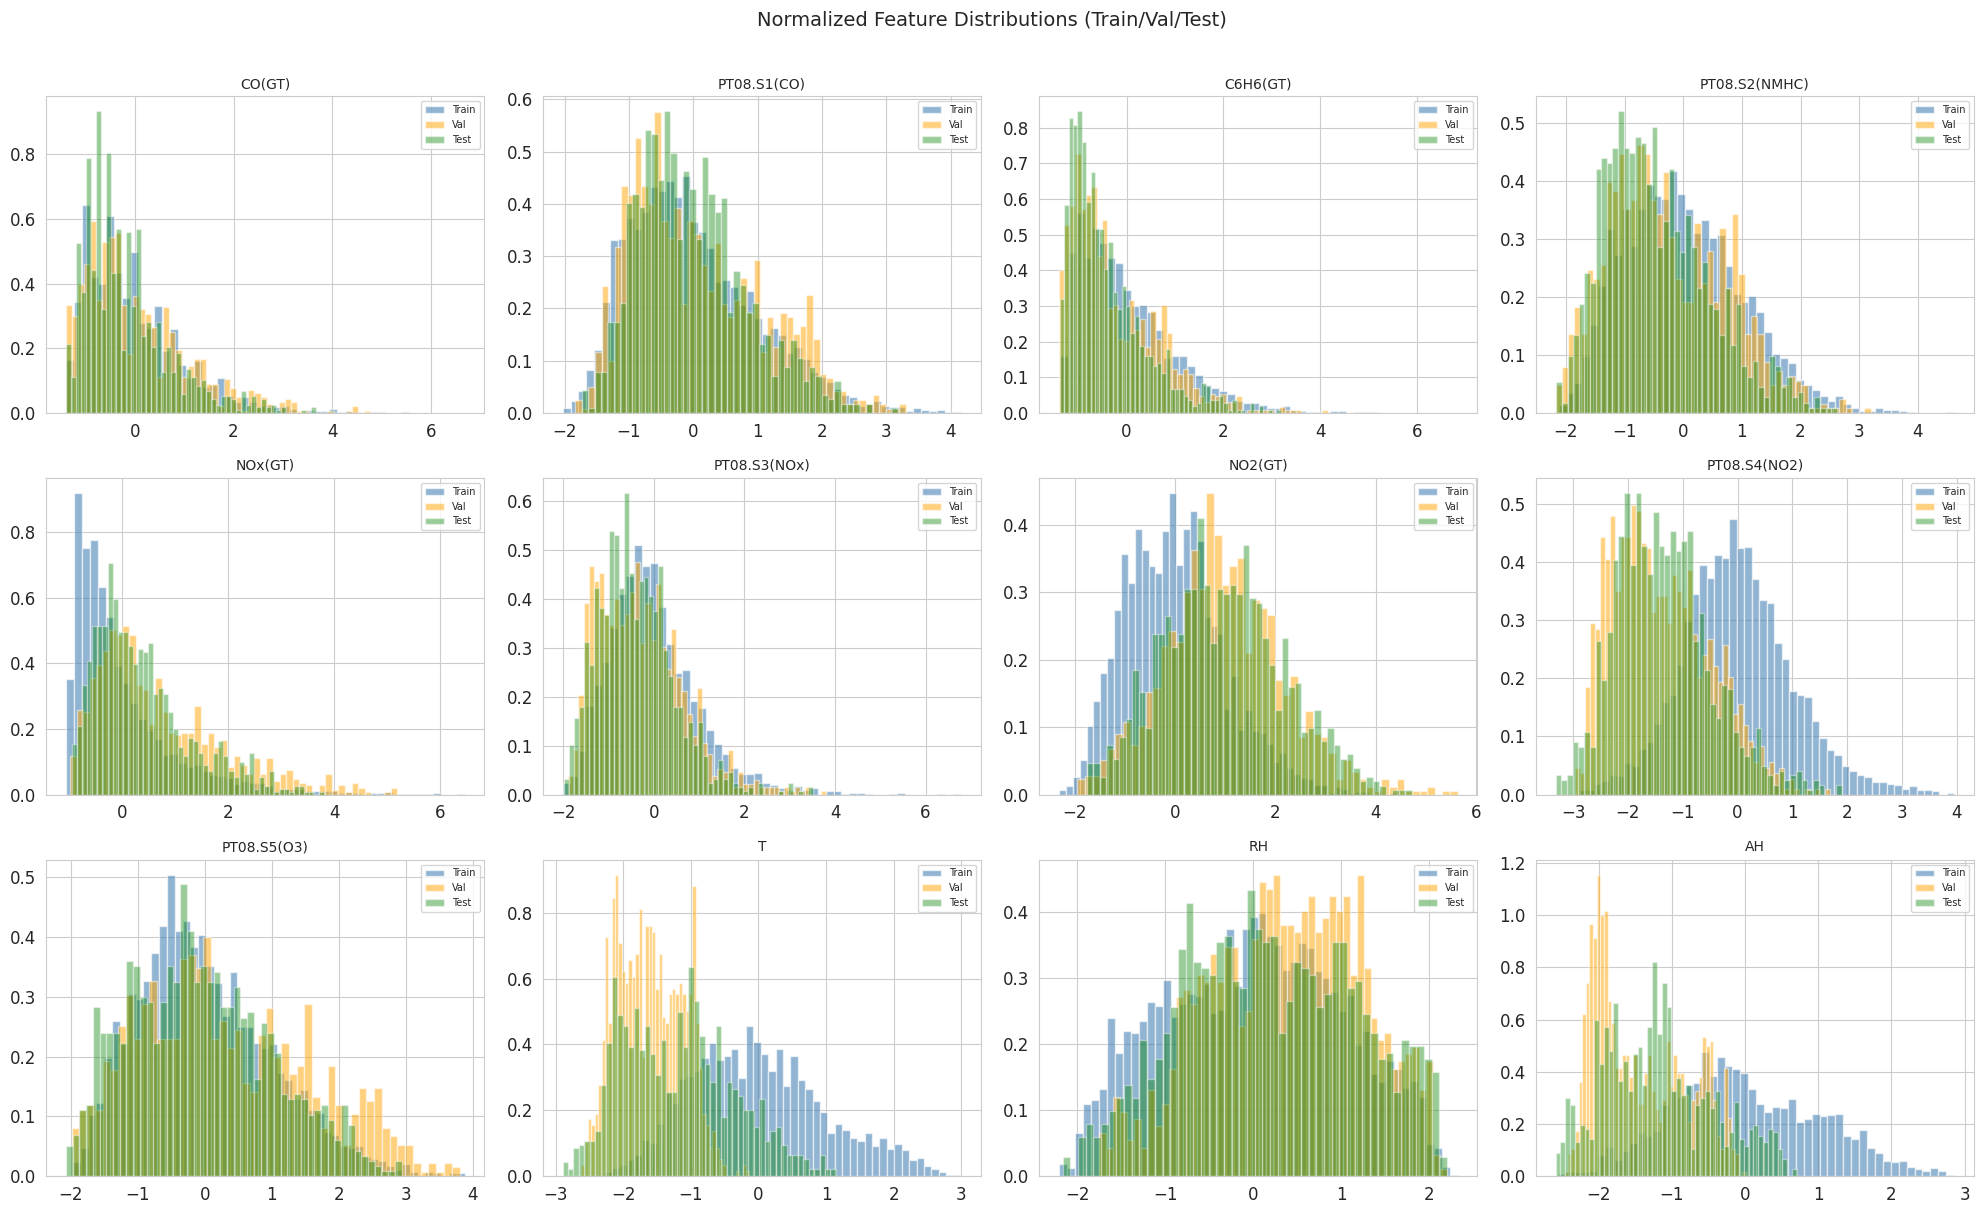

In [19]:
# Cell 16: Verify Normalized Distributions
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols_final):
    if i < len(axes):
        axes[i].hist(train_norm[col].values, bins=50, alpha=0.6, color='steelblue', label='Train', density=True)
        axes[i].hist(val_norm[col].values, bins=50, alpha=0.5, color='orange', label='Val', density=True)
        axes[i].hist(test_norm[col].values, bins=50, alpha=0.4, color='green', label='Test', density=True)
        axes[i].set_title(col, fontsize=10)
        axes[i].legend(fontsize=7)

for j in range(len(feature_cols_final), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Normalized Feature Distributions (Train/Val/Test)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(str(project_root / 'outputs' / 'air_quality_normalized_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Cell 17: PyTorch Dataset Class
class AirQualityTimeSeriesDataset(Dataset):
    """
    Sliding window dataset for time series forecasting.
    
    Input shape:  (seq_len, num_features)
    Target shape: (1,) — next-step value of target column
    
    For models expecting (batch, seq_len, features).
    """
    def __init__(self, df_normalized, feature_cols, target_col, seq_len=24, forecast_horizon=1):
        self.seq_len = seq_len
        self.forecast_horizon = forecast_horizon
        self.feature_cols = feature_cols
        self.target_col = target_col
        
        features = df_normalized[feature_cols].values.astype(np.float32)
        targets = df_normalized[target_col].values.astype(np.float32)
        
        self.sequences = []
        self.targets = []
        
        for i in range(len(features) - seq_len - forecast_horizon + 1):
            self.sequences.append(features[i : i + seq_len])
            self.targets.append(targets[i + seq_len + forecast_horizon - 1])
        
        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.targets = np.array(self.targets, dtype=np.float32)
        
        print(f"  Created dataset: {self.sequences.shape[0]} samples | "
              f"X shape: {self.sequences.shape} | y shape: {self.targets.shape}")
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx]), torch.tensor(self.targets[idx])

print("✅ AirQualityTimeSeriesDataset defined")

✅ AirQualityTimeSeriesDataset defined


In [21]:
# Cell 18: Create Datasets and DataLoaders
print("="*60)
print("CREATING DATASETS & DATALOADERS")
print("="*60)

print("\nTrain:")
train_dataset = AirQualityTimeSeriesDataset(
    train_norm, feature_cols_final, TARGET_COL, seq_len=SEQ_LEN, forecast_horizon=FORECAST_HORIZON
)

print("Val:")
val_dataset = AirQualityTimeSeriesDataset(
    val_norm, feature_cols_final, TARGET_COL, seq_len=SEQ_LEN, forecast_horizon=FORECAST_HORIZON
)

print("Test:")
test_dataset = AirQualityTimeSeriesDataset(
    test_norm, feature_cols_final, TARGET_COL, seq_len=SEQ_LEN, forecast_horizon=FORECAST_HORIZON
)

# Reproducible DataLoaders
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
    num_workers=0, generator=g, drop_last=False
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"\n{'='*60}")
print(f"DATALOADER SUMMARY")
print(f"{'='*60}")
print(f"Train: {len(train_loader)} batches × {BATCH_SIZE} = {len(train_dataset)} samples")
print(f"Val:   {len(val_loader)} batches × {BATCH_SIZE} = {len(val_dataset)} samples")
print(f"Test:  {len(test_loader)} batches × {BATCH_SIZE} = {len(test_dataset)} samples")
print(f"\nInput shape per sample:  ({SEQ_LEN}, {num_features})")
print(f"Batch shape:             ({BATCH_SIZE}, {SEQ_LEN}, {num_features})")
print(f"Target: {TARGET_COL} (next hour)")

CREATING DATASETS & DATALOADERS

Train:
  Created dataset: 5420 samples | X shape: (5420, 24, 12) | y shape: (5420,)
Val:
  Created dataset: 1142 samples | X shape: (1142, 24, 12) | y shape: (1142,)
Test:
  Created dataset: 1142 samples | X shape: (1142, 24, 12) | y shape: (1142,)

DATALOADER SUMMARY
Train: 85 batches × 64 = 5420 samples
Val:   18 batches × 64 = 1142 samples
Test:  18 batches × 64 = 1142 samples

Input shape per sample:  (24, 12)
Batch shape:             (64, 24, 12)
Target: C6H6(GT) (next hour)


In [22]:
# Cell 19: Verify Batch Shapes
print("="*60)
print("BATCH SHAPE VERIFICATION")
print("="*60)

X_batch, y_batch = next(iter(train_loader))
print(f"X_batch shape: {X_batch.shape}  →  (batch, seq_len, features)")
print(f"y_batch shape: {y_batch.shape}  →  (batch,)")
print(f"X dtype: {X_batch.dtype}")
print(f"y dtype: {y_batch.dtype}")
print(f"\nX_batch[0] stats: mean={X_batch[0].mean():.4f}, std={X_batch[0].std():.4f}")
print(f"y_batch stats: mean={y_batch.mean():.4f}, std={y_batch.std():.4f}")

# Verify denormalization round-trip
sample_y = y_batch[0].item()
denorm_y = denormalize(sample_y, TARGET_COL, train_mean, train_std)
renorm_y = (denorm_y - train_mean[TARGET_COL]) / train_std[TARGET_COL]
print(f"\nDenormalize round-trip: normalized={sample_y:.4f} → original={denorm_y:.4f} → re-normalized={renorm_y:.4f}")
assert abs(sample_y - renorm_y) < 1e-5, "Denormalization round-trip failed!"
print("✅ Denormalization round-trip verified")

BATCH SHAPE VERIFICATION
X_batch shape: torch.Size([64, 24, 12])  →  (batch, seq_len, features)
y_batch shape: torch.Size([64])  →  (batch,)
X dtype: torch.float32
y dtype: torch.float32

X_batch[0] stats: mean=-0.2144, std=0.6089
y_batch stats: mean=0.1391, std=0.9382

Denormalize round-trip: normalized=-0.0752 → original=10.3000 → re-normalized=-0.0752
✅ Denormalization round-trip verified


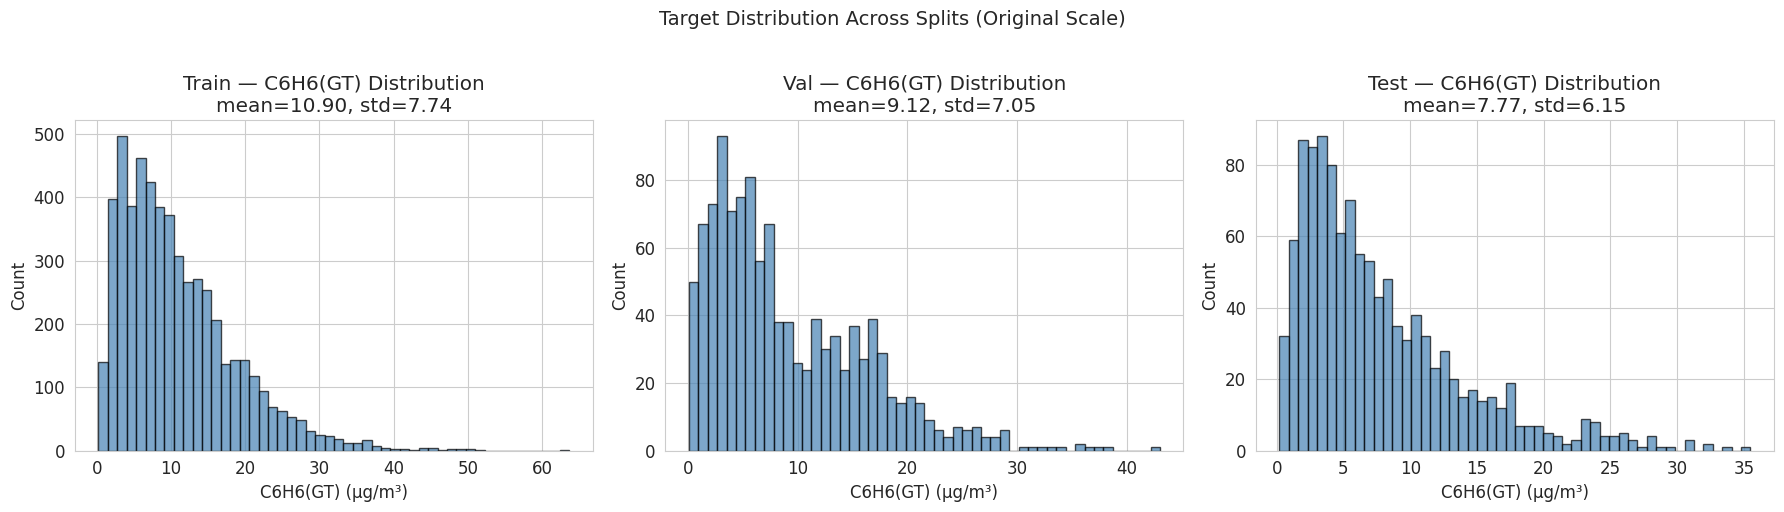

In [23]:
# Cell 20: Target Distribution in Train/Val/Test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, dataset) in zip(axes, [('Train', train_dataset), ('Val', val_dataset), ('Test', test_dataset)]):
    targets = dataset.targets
    # Denormalize for interpretability
    targets_original = targets * train_std[TARGET_COL] + train_mean[TARGET_COL]
    
    ax.hist(targets_original, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{name} — {TARGET_COL} Distribution\n'
                 f'mean={targets_original.mean():.2f}, std={targets_original.std():.2f}')
    ax.set_xlabel(f'{TARGET_COL} (µg/m³)')
    ax.set_ylabel('Count')

plt.suptitle('Target Distribution Across Splits (Original Scale)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(str(project_root / 'outputs' / 'air_quality_target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 21: Autocorrelation Analysis (motivates seq_len choice)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

target_series = train_df[TARGET_COL].values

# ACF
plot_acf(target_series, lags=72, ax=axes[0, 0], title=f'ACF — {TARGET_COL}')
# PACF
plot_pacf(target_series, lags=72, ax=axes[0, 1], title=f'PACF — {TARGET_COL}', method='ywm')

# Also for CO
co_series = train_df['CO(GT)'].values
plot_acf(co_series, lags=72, ax=axes[1, 0], title='ACF — CO(GT)')
plot_pacf(co_series, lags=72, ax=axes[1, 1], title='PACF — CO(GT)', method='ywm')

plt.suptitle(f'Autocorrelation Analysis (seq_len={SEQ_LEN} covers daily cycle)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(str(project_root / 'outputs' / 'air_quality_autocorrelation.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Using seq_len={SEQ_LEN} captures the full 24-hour daily cycle")

In [24]:
# Cell 22: Summary & Model-Ready Config
print("="*70)
print("EDA & PREPROCESSING SUMMARY")
print("="*70)

print(f"""
Dataset:          Air Quality UCI (hourly readings, March 2004 – February 2005)
Original shape:   {raw_df.shape}
Cleaned shape:    {df.shape}
Dropped features: NMHC(GT) (~90% missing)
Missing handling: Linear interpolation (limit=5) + ffill/bfill (limit=3)

Features ({num_features}):
  Sensors:     {sensor_cols}
  Ground Truth: {[c for c in gt_cols if c != 'NMHC(GT)']}
  Meteo:       {meteo_cols}

Target:           {TARGET_COL} (Benzene concentration, µg/m³)
Task:             Next-hour forecasting (horizon=1)
Sequence length:  {SEQ_LEN} (covers full daily cycle)

Normalization:    Z-score (fit on train only)
Split:            Temporal (no shuffle)
  Train:  {len(train_dataset):,} samples  ({len(train_df):,} hours)
  Val:    {len(val_dataset):,} samples  ({len(val_df):,} hours)
  Test:   {len(test_dataset):,} samples  ({len(test_df):,} hours)

DataLoader shapes:
  X: (batch={BATCH_SIZE}, seq={SEQ_LEN}, features={num_features})
  y: (batch={BATCH_SIZE},)

Normalization stats: {norm_stats_path}
""")

print("Model-ready config dict:")
config = {
    'target_col': TARGET_COL,
    'feature_cols': feature_cols_final,
    'num_features': num_features,
    'seq_len': SEQ_LEN,
    'forecast_horizon': FORECAST_HORIZON,
    'batch_size': BATCH_SIZE,
    'train_samples': len(train_dataset),
    'val_samples': len(val_dataset),
    'test_samples': len(test_dataset),
}

for k, v in config.items():
    if isinstance(v, list):
        print(f"  {k}: [{len(v)} items]")
    else:
        print(f"  {k}: {v}")

EDA & PREPROCESSING SUMMARY

Dataset:          Air Quality UCI (hourly readings, March 2004 – February 2005)
Original shape:   (9357, 14)
Cleaned shape:    (7776, 13)
Dropped features: NMHC(GT) (~90% missing)
Missing handling: Linear interpolation (limit=5) + ffill/bfill (limit=3)

Features (12):
  Sensors:     ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
  Ground Truth: ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
  Meteo:       ['T', 'RH', 'AH']

Target:           C6H6(GT) (Benzene concentration, µg/m³)
Task:             Next-hour forecasting (horizon=1)
Sequence length:  24 (covers full daily cycle)

Normalization:    Z-score (fit on train only)
Split:            Temporal (no shuffle)
  Train:  5,420 samples  (5,444 hours)
  Val:    1,142 samples  (1,166 hours)
  Test:   1,142 samples  (1,166 hours)

DataLoader shapes:
  X: (batch=64, seq=24, features=12)
  y: (batch=64,)

Normalization stats: /home/rdb/Documents/nirban_documents/python_programs/co

BASELINE: Persistence Model (predict y_t = x_{t-1})
  MAE:  2.3601 µg/m³
  RMSE: 3.7515 µg/m³
  R²:   0.6284


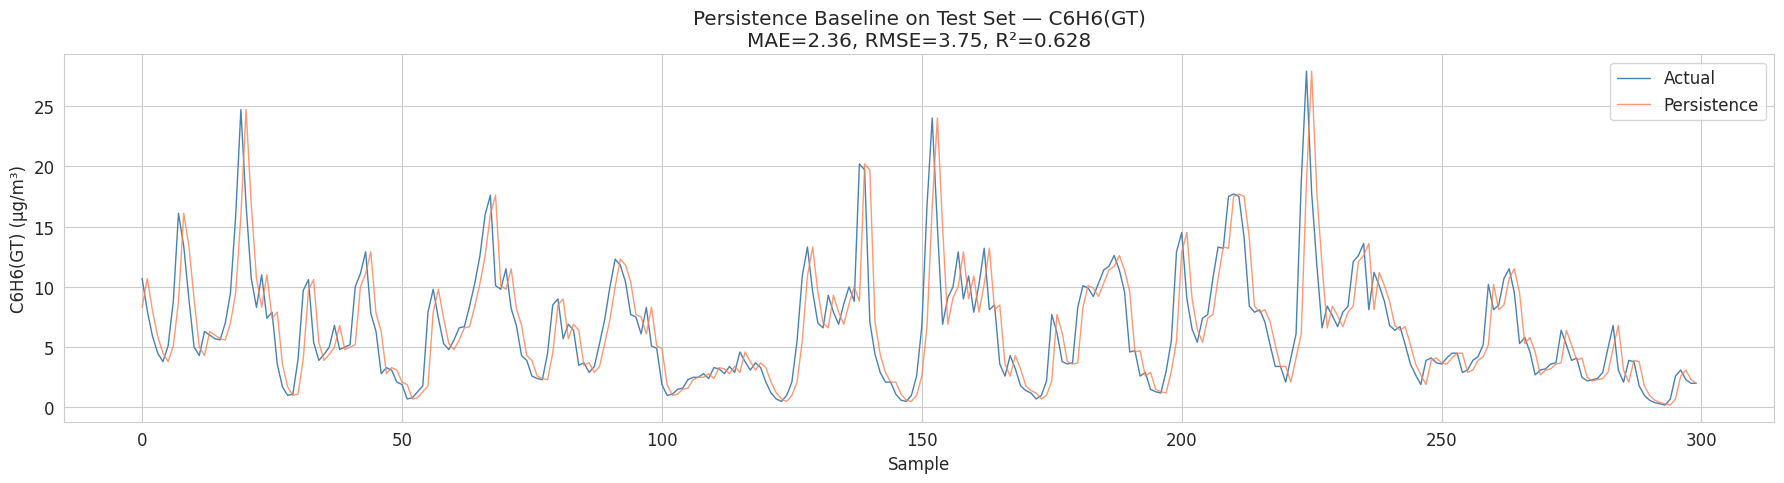


✅ Baseline established. LSTM/GRU/Transformer should beat this.


In [25]:
# Cell 23: Quick Baseline — Persistence Model (predict last value)
print("="*60)
print("BASELINE: Persistence Model (predict y_t = x_{t-1})")
print("="*60)

target_idx = feature_cols_final.index(TARGET_COL)

preds_persistence = []
actuals = []

for X, y in test_loader:
    # Last timestep of target feature in the input window
    last_val = X[:, -1, target_idx]
    preds_persistence.append(last_val.numpy())
    actuals.append(y.numpy())

preds_persistence = np.concatenate(preds_persistence)
actuals = np.concatenate(actuals)

# Denormalize
preds_orig = denormalize(preds_persistence, TARGET_COL, train_mean, train_std)
actuals_orig = denormalize(actuals, TARGET_COL, train_mean, train_std)

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(actuals_orig, preds_orig)
rmse = np.sqrt(mean_squared_error(actuals_orig, preds_orig))
r2 = r2_score(actuals_orig, preds_orig)

print(f"  MAE:  {mae:.4f} µg/m³")
print(f"  RMSE: {rmse:.4f} µg/m³")
print(f"  R²:   {r2:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(actuals_orig[:300], label='Actual', color='steelblue', linewidth=1)
ax.plot(preds_orig[:300], label='Persistence', color='coral', linewidth=1, alpha=0.8)
ax.set_title(f'Persistence Baseline on Test Set — {TARGET_COL}\nMAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}')
ax.set_xlabel('Sample')
ax.set_ylabel(f'{TARGET_COL} (µg/m³)')
ax.legend()
plt.tight_layout()
plt.savefig(str(project_root / 'outputs' / 'air_quality_persistence_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Baseline established. LSTM/GRU/Transformer should beat this.")